## Making your own performance metric

Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

If you want to optimize a metric that is not available in scikit-learn, you can create one. In this notebook, we'll explore how.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, make_scorer

In [2]:
# if you want more information about the dataset for this demo:

# scikit-learn dataset
# https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

# dataset information: UCI Machine Learning Repository
# https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)
    
# in short, classification problem to predict whether the tumor
# is malignant or benign

# load dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
y = y.map({0:1, 1:0})

# Keep a small, stratified test set for the final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=0
)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# percentage of benign (0) and malignant tumors (1)

y.value_counts() / len(y)

target
0    0.627417
1    0.372583
Name: count, dtype: float64

## Confusion matrix

We will use the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
) function from scikit-learn to return the false positives, false negatives, true positives, and true negatives used to construct the false negative rate.


TN | FP

FN | TP

## False Negative Rate

Because this is a dangerous disease, I want to minimize the number of false-negative cases (the false negative rate). That is, I want to minimize the number of cases where a malignant tumor (1) is wrongly classified as benign (0). This way, we can offer treatment to as many patients as possible.

Because the **False Negative Rate** is not available directly in scikit-learn, we need to create the metric ourselves.

We will use the [make_scorer](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) function from scikit-learn:

In [4]:
# Return the false negative rate from the ground-truth and
# predicted class labels.

def fnr(y_true, y_pred):
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    
    FNR = fn / (tp + fn)
    
    return FNR    

In [5]:
fnr_score = make_scorer(
    fnr,
    greater_is_better=False,  # lower FNR is better
    response_method="predict",  # use predicted class labels
)

In [6]:
# random forests
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=1, random_state=0, n_jobs=-1)

# hyperparameter space
rf_param_grid = dict(
    n_estimators=[10, 20, 50, 100, 200, 500, 1000, 2000],
    max_depth=[1, 2, 3, 4],
)

# search
clf = GridSearchCV(rf_model,
                   rf_param_grid,
                   scoring=fnr_score,
                   cv=5)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'max_depth': 4, 'n_estimators': 20}

In [7]:
# Evaluate the selected model once on the held-out test set.
fnr(y_test, search.predict(X_test))

np.float64(0.047619047619047616)

In [8]:
results = pd.DataFrame(search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score']]

results.head()

,params,mean_test_score,std_test_score
0,"{'max_depth': 1, 'n_estimators': 10}",-0.193657,0.067594
1,"{'max_depth': 1, 'n_estimators': 20}",-0.136302,0.026459
2,"{'max_depth': 1, 'n_estimators': 50}",-0.151822,0.048176
3,"{'max_depth': 1, 'n_estimators': 100}",-0.167611,0.069964
4,"{'max_depth': 1, 'n_estimators': 200}",-0.167611,0.054369


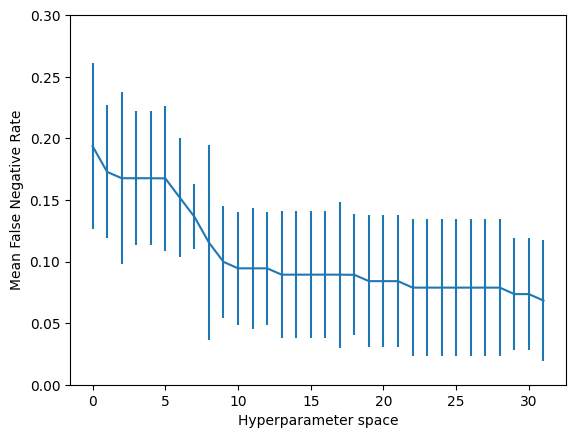

In [9]:
results['mean_fnr'] = -results['mean_test_score']

results.sort_values(by='mean_fnr', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_fnr'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylim(0, 0.3)
plt.ylabel('Mean False Negative Rate')
plt.xlabel('Hyperparameter space')
plt.show()

Note that in the previous plot I draw the FNR instead of the negative of the FNR, which is what I show in the video. That's why the plots are inverted here!

## Scoring Function that needs a probability

Scikit-learn also provides [TunedThresholdClassifierCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TunedThresholdClassifierCV.html), which tunes a decision threshold using cross-validation. Threshold tuning is outside the scope of this course, so here we use a fixed threshold to illustrate how a scorer can consume predicted probabilities.

In [10]:
def fnr(y_true, y_pred):

    y_pred_class = np.where(y_pred > 0.37, 1, 0)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred_class, labels=[0, 1]).ravel()

    FNR = fn / (tp + fn)

    return FNR

In [11]:
fnr_score = make_scorer(
    fnr,
    greater_is_better=False,  # lower FNR is better
    response_method="predict_proba",  # use positive-class probabilities
)

In [12]:
# random forests
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=1, random_state=0, n_jobs=-1)

# hyperparameter space
rf_param_grid = dict(
    n_estimators=[10, 20, 50, 100, 200, 500, 1000, 2000],
    max_depth=[1, 2, 3, 4],
)

# search
clf = GridSearchCV(rf_model,
                   rf_param_grid,
                   scoring=fnr_score,
                   cv=5)

search = clf.fit(X_train, y_train)

# best hyperparameters
search.best_params_

{'max_depth': 3, 'n_estimators': 20}

In [13]:
# Evaluate the selected model once on the held-out test set.
fnr(y_test, search.predict_proba(X_test)[:, 1])

np.float64(0.047619047619047616)

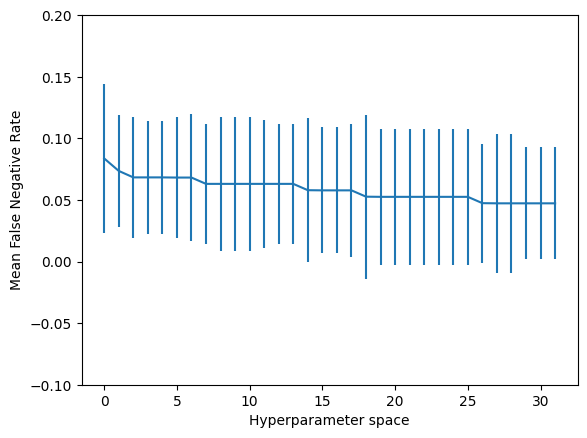

In [15]:
results = pd.DataFrame(search.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score']]

results['mean_fnr'] = -results['mean_test_score']

results.sort_values(by='mean_fnr', ascending=False, inplace=True)

results.reset_index(drop=True, inplace=True)

results['mean_fnr'].plot(
    yerr=[results['std_test_score'], results['std_test_score']], subplots=True)

plt.ylim(-0.1, 0.2)
plt.ylabel('Mean False Negative Rate')
plt.xlabel('Hyperparameter space')
plt.show()

Similarly, I plot the MSE instead of the negative of the MSE, that's the proper way of displaying the plot, which is the opposite of what I do in the video!

Now that we modified the scoring function using a probability threshold that better represents the distribution of the class in the data, we are able to minimize further the FNR.